# ASL Sign Language Recognition - Model Inference

This notebook performs real-time inference on ASL videos using trained deep learning models. It extracts landmarks from video frames and predicts the corresponding sign language word.

## Overview
- **Input**: Video files (.mp4) containing ASL signs
- **Processing**: MediaPipe Holistic landmark extraction + sliding window inference
- **Models**: Supports both Transformer and GRU architectures
- **Output**: Predicted ASL word with confidence scores and temporal analysis

## Key Features
- Sliding window inference with temporal smoothing
- Exponential Moving Average (EMA) for stable predictions
- Majority voting for final classification
- Real-time landmark extraction from video
- Interactive video upload and visualization

---

## 1. Install Required Dependencies

Install MediaPipe and OpenCV for landmark detection and video processing.

In [1]:
!pip uninstall -y mediapipe
!pip install mediapipe==0.10.9

ERROR: Could not find a version that satisfies the requirement mediapipe==0.10.9 (from versions: 0.10.13, 0.10.14, 0.10.15, 0.10.18, 0.10.20, 0.10.21, 0.10.30, 0.10.31, 0.10.32)
ERROR: No matching distribution found for mediapipe==0.10.9


In [2]:
!pip install mediapipe opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 72.2 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 10.9 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


## 2. Mount Google Drive

Connect to Google Drive to access trained model checkpoints and vocabulary files.

In [1]:
# Commented out for local execution
# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)
print("Running locally - Google Drive mount not needed")

Running locally - Google Drive mount not needed


In [ ]:
# Running locally (required)
# updating the folders path accordingly

## 3. Import Required Libraries

Import all necessary libraries for the inference pipeline:

### Core Libraries:
- **os, pathlib**: File system operations
- **cv2 (OpenCV)**: Video reading and frame processing
- **numpy**: Numerical operations on landmark arrays
- **pandas**: CSV handling for vocabulary
- **torch**: PyTorch for model inference

### Specialized Libraries:
- **mediapipe**: Holistic landmark detection (pose + hands)
- **IPython.display**: Video embedding in notebook
- **base64**: Video encoding for HTML display
- **collections.deque**: Sliding window buffer
- **time, math**: Timing and mathematical operations

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import mediapipe as mp
from pathlib import Path
from IPython.display import HTML, display
from base64 import b64encode
import time
import math
from collections import deque

## 4. Detect Compute Device

Determine whether to use GPU (CUDA) or CPU for inference.

**GPU acceleration** provides significantly faster inference (~10-50x speedup), especially important for real-time video processing.

In [2]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE

device(type='cuda')

## 5. Configure Model and Data Paths

Define paths to model checkpoints, vocabulary, and inference parameters:

### Model Selection:
- **MODEL_TYPE**: Choose between 'gru' or 'transformer' architecture
- **GRU_CKPT**: Path to trained GRU model checkpoint
- **TRANSFORMER_CKPT**: Path to trained Transformer model checkpoint

### Data Paths:
- **WORDS_CSV**: Vocabulary file with 100 ASL words/glosses

### Inference Parameters:
- **T_SEQ (32)**: Fixed sequence length for temporal window
  - Matches the training configuration
  - Determines how many frames are analyzed together

**Note**: Change MODEL_TYPE to switch between architectures. Both models should be trained on the same vocabulary.

In [8]:
MODEL_TYPE = 'transformer'  # 'gru' or 'transformer'
GRU_CKPT = Path(r'd:\Live Sign Language Translator UI\model\asl-model-gru\best.pth') # Change according to your local address
TRANSFORMER_CKPT = Path(r'd:\Live Sign Language Translator UI\model\asl-model-transformer\best-v1.pth') # Change according to your local address
WORDS_CSV = Path(r'd:\Live Sign Language Translator UI\model\95_words.csv') # Change according to your local address
T_SEQ = 60


In [5]:
print('Notebook working dir:', Path.cwd())
p = Path('./asl-model-transformer/best-v1.pth')
print('Given path:', p)
print('Resolved:', p.resolve())
print('Exists?:', p.exists())
if p.exists():
    print('File size:', p.stat().st_size)
else: 
    print('Directory listing of parent:', list(p.parent.iterdir()) if p.parent.exists() else 'parent not found')

Notebook working dir: d:\Live Sign Language Translator UI\model
Given path: asl-model-transformer\best-v1.pth
Resolved: D:\Live Sign Language Translator UI\model\asl-model-transformer\best-v1.pth
Exists?: True
File size: 26895103


In [8]:
import os
os.getcwd()

'd:\\Live Sign Language Translator UI\\model'

## 6. Define Video Display Function

Create a utility function to embed and display video files directly in the notebook.

**How it works**:
1. Reads video file as binary data
2. Encodes to base64 string
3. Embeds in HTML5 video player
4. Displays with interactive controls (play, pause, seek)

**Usage**: Allows viewing uploaded videos or predictions without leaving the notebook interface.

In [6]:
def show_video(path, width=480):
    '''
    Displays an MP4 video file in a Jupyter/Colab notebook.

    Reads the video file, encodes it to base64, and embeds it via HTML.

    Args:
        path (str): The file path to the MP4 video.
        width (int): The display width of the video player in pixels.
    '''
    mp4 = Path(path)
    if not mp4.exists():
        print('File not found:', path)
        return
    video_bytes = mp4.read_bytes()
    b64 = b64encode(video_bytes).decode()
    html = f'''
    <video width="{width}" controls>
        <source src="data:video/mp4;base64,{b64}" type="video/mp4">
    </video>
    '''
    display(HTML(html))

## 7. Define Label Loading Function

Create a function to load the ASL vocabulary from the CSV file.

**Process**:
- Reads the words CSV containing target signs
- Extracts unique glosses (sign names)
- Sorts alphabetically for consistent ordering
- Returns as a list

**Purpose**: Establishes the canonical label ordering that matches the training configuration.

In [10]:
def load_label_list(words_csv):
    '''
    Loads a list of labels from the given CSV file.

    Args:
        words_csv (Path): Path to the CSV file containing the labels.
    Returns:
        list: List of labels.
    '''
    df = pd.read_csv(str(words_csv))
    labels = sorted(df['gloss'].astype(str).unique().tolist())
    return labels

## 8. Load Vocabulary and Count Classes

Load the complete ASL vocabulary and determine the number of output classes.

**Result**:
- `LABELS`: Sorted list of 100 ASL sign names
- `NUM_CLASSES`: Total vocabulary size (used for model initialization)

This must match the vocabulary used during training.

In [11]:
LABELS = load_label_list(WORDS_CSV)
NUM_CLASSES = len(LABELS)
print(f'{NUM_CLASSES} classes loaded.')

95 classes loaded.


## 9. Create Label-Index Mappings

Build bidirectional dictionaries for converting between labels and model outputs.

**Mappings**:

1. **label2idx**: Gloss string → Integer index
   - Maps sign names to model output indices
   - Example: `{"hello": 0, "thank": 1, ...}`

2. **idx2label**: Integer index → Gloss string
   - Converts model predictions back to human-readable labels
   - Example: `{0: "hello", 1: "thank", ...}`
   - Used for displaying inference results

These mappings are essential for interpreting model outputs.

In [12]:
label2idx = {lbl: idx for idx, lbl in enumerate(LABELS)}
idx2label = {v: k for k, v in label2idx.items()}

## 10. Define Model Architecture Classes

Define both Transformer and GRU model architectures for ASL recognition.

### PositionalEncoding Module:
- Adds sinusoidal position information to Transformer inputs
- Pre-computes position encodings up to max_len (512)
- Uses sin/cos functions at different frequencies
- Enables the model to understand temporal order

### LandmarkTransformer Model:
**Architecture**:
1. **Input projection**: (227) → (128) dimensions
2. **Positional encoding**: Adds temporal information
3. **Transformer encoder**: 3 layers, 4 attention heads
   - Multi-head self-attention learns frame relationships
   - Feed-forward network (256 dims)
   - GELU activation, dropout regularization
4. **Temporal pooling**: Aggregates across time
5. **Classification head**: (128) → (100 classes)

**Purpose**: Captures complex temporal dependencies in sign language through self-attention mechanisms.

---

**Note**: These are the same architectures used during training. The model definitions must match exactly for checkpoint loading to succeed.

In [13]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:x.size(1), :]

class LandmarkTransformer(nn.Module):
    def __init__(self, in_dim: int, num_classes: int, d_model=128, nhead=4, nlayers=3, ffn=256, dropout=0.1):
        super().__init__()
        self.input_fc = nn.Linear(in_dim, d_model)
        self.pos = PositionalEncoding(d_model, max_len=512)
        encoder_layer = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward=ffn, dropout=dropout, activation='gelu', batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=nlayers)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.cls = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, num_classes))

    def forward(self, x):
        x = self.input_fc(x)
        x = self.pos(x)
        x = x.permute(1,0,2) # T x B x D
        x = self.transformer(x)
        x = x.permute(1,2,0) # B x D x T
        x = self.pool(x).squeeze(-1) # B x D
        logits = self.cls(x)
        return logits

## 11. Define GRU Model Architecture

Define an alternative GRU-based recurrent model for sequence classification.

**Architecture**:

1. **GRU Layer**:
   - Gated Recurrent Unit (256 hidden units)
   - Processes sequences sequentially
   - Captures temporal dependencies through hidden states
   - `batch_first=True`: Input shape (batch, time, features)

2. **Temporal Aggregation**:
   - Mean pooling across time dimension
   - Summarizes entire sequence into single vector

3. **Classification Head**:
   - Layer normalization for stability
   - Linear layer: (256) → (100 classes)

**Comparison with Transformer**:
- **Pros**: Simpler, fewer parameters, faster inference
- **Cons**: Sequential processing (can't parallelize), may miss long-range dependencies
- **Use case**: Good alternative when computational resources are limited

Both models operate on the same 227-dimensional landmark features.

In [11]:
class GRUModel(nn.Module):
    def __init__(self, in_dim, num_classes, hidden=256, num_layers=1, bidirectional=False, dropout=0.1):
        super().__init__()
        self.rnn = nn.GRU(input_size=in_dim, hidden_size=hidden, num_layers=num_layers,
                            batch_first=True, bidirectional=bidirectional, dropout=dropout if num_layers>1 else 0.0)
        self.fc = nn.Sequential(nn.LayerNorm(hidden * (2 if bidirectional else 1)),
                                nn.Linear(hidden * (2 if bidirectional else 1), num_classes))

    def forward(self, x):
        out, _ = self.rnn(x)
        out = out.mean(dim=1)
        out = self.fc(out)
        return out

## 12. Define Model Initialization Function

Create a factory function to instantiate the specified model architecture.

**How it works**:
- Takes model type as parameter ('transformer' or 'gru')
- Initializes the corresponding architecture with standard hyperparameters
- Returns the model ready for checkpoint loading

**Parameters**:
- `in_dim=227`: Landmark feature dimension (pose + hands)
- `num_classes`: Vocabulary size (100 ASL words)
- Architecture-specific parameters match training configuration

**Purpose**: Provides a unified interface for creating different model types.

In [14]:
def init_model(in_dim, num_classes, model_type = 'transformer'):
    '''
    Initializes the specified model architecture.

    Args:
        in_dim (int): Input dimension.
        num_classes (int): Number of output classes.
        model_type (str): Type of model to initialize. Default is 'transformer'.
    Returns:
        nn.Module: Initialized model.
    '''
    if model_type == 'transformer':
        model = LandmarkTransformer(in_dim=in_dim, num_classes=num_classes, d_model=128, nhead=4, nlayers=3, ffn=256, dropout=0.1)
    elif model_type == 'gru':
        model = GRUModel(in_dim=in_dim, num_classes=num_classes, hidden=256, num_layers=1, bidirectional=False, dropout=0.1)
    else:
        raise ValueError('Unknown model type')
    return model

## 13. Define Model Loading Function

Create a function to load a trained model from a checkpoint file.

**Process**:

1. **Initialize Model**:
   - Creates model architecture based on specified type
   - Moves to appropriate device (GPU/CPU)

2. **Select Checkpoint**:
   - Chooses correct checkpoint path based on model type
   - Validates that checkpoint file exists

3. **Load Weights**:
   - Reads checkpoint file (contains model_state, optimizer_state, etc.)
   - Extracts model weights from 'model_state' key
   - Loads weights into model using `load_state_dict()`

4. **Set Evaluation Mode**:
   - Calls `model.eval()` to disable dropout and batch norm training behavior
   - Ensures deterministic, consistent predictions

**Returns**: Fully loaded model ready for inference.

**Error Handling**: Raises FileNotFoundError if checkpoint is missing.

In [15]:
def load_model_and_checkpoint(model_type):
    '''
    Initializes the model, loads weights from the checkpoint, and sets to eval mode.

    Args:
        model_type (str): The architecture to load ('transformer' or 'gru').

    Returns:
        torch.nn.Module: The loaded model on the configured device.
    '''
    model = init_model(in_dim=227, num_classes=NUM_CLASSES, model_type=model_type)
    model.to(DEVICE)

    if model_type == 'transformer':
        ckpt_path = TRANSFORMER_CKPT
    elif model_type == 'gru':
        ckpt_path = GRU_CKPT
    else:
        raise ValueError('Unknown model type')

    # Ensure ckpt_path is a Path object (handles str or Path inputs)
    ckpt_path = Path(ckpt_path)

    if not ckpt_path.exists():
        raise FileNotFoundError(f'Checkpoint not found: {ckpt_path}')

    ck = torch.load(str(ckpt_path), map_location=DEVICE)
    state = ck['model_state']

    model.load_state_dict(state)
    model.eval()
    return model

## 14. Load the Model

Instantiate and load the selected model from its checkpoint.

**What happens**:
- Calls `load_model_and_checkpoint()` with the configured MODEL_TYPE
- Loads either GRU or Transformer weights
- Model is now ready for inference on videos

**Result**: `model` variable contains the loaded, eval-mode model on the correct device.

In [16]:
model = load_model_and_checkpoint(MODEL_TYPE)

RuntimeError: Error(s) in loading state_dict for LandmarkTransformer:
	Unexpected key(s) in state_dict: "transformer.layers.3.self_attn.in_proj_weight", "transformer.layers.3.self_attn.in_proj_bias", "transformer.layers.3.self_attn.out_proj.weight", "transformer.layers.3.self_attn.out_proj.bias", "transformer.layers.3.linear1.weight", "transformer.layers.3.linear1.bias", "transformer.layers.3.linear2.weight", "transformer.layers.3.linear2.bias", "transformer.layers.3.norm1.weight", "transformer.layers.3.norm1.bias", "transformer.layers.3.norm2.weight", "transformer.layers.3.norm2.bias". 
	size mismatch for input_fc.weight: copying a param with shape torch.Size([256, 227]) from checkpoint, the shape in current model is torch.Size([128, 227]).
	size mismatch for input_fc.bias: copying a param with shape torch.Size([256]) from checkpoint, the shape in current model is torch.Size([128]).
	size mismatch for pos.pe: copying a param with shape torch.Size([512, 256]) from checkpoint, the shape

## 15. Define Sequence Normalization Function

Implement the same normalization used during training to ensure consistency.

**Normalization process**:

1. **Extract Coordinates**:
   - Separates landmark coordinates from presence flags
   - Focuses on indices 0-162 (pose + left hand coords) and 163-226 (right hand coords)
   - Reshapes to (frames, landmarks, 3) for easier manipulation

2. **Identify Visible Landmarks**:
   - Creates mask of non-zero landmarks (actually detected)
   - Filters out padded/missing landmarks

3. **Per-Frame Normalization**:
   - For each frame with detected landmarks:
     - Calculates centroid (mean x,y position)
     - Computes average distance from centroid (scale)
     - Centers coordinates by subtracting centroid
     - Scales by dividing by average distance

4. **Reconstruct Array**:
   - Puts normalized coordinates back into original structure
   - Preserves presence flags unchanged

**Purpose**: Makes predictions invariant to:
- Signer's position in frame (translation)
- Distance from camera (scale)
- Individual body size differences

**Critical**: Must match the training normalization exactly for accurate predictions.

In [15]:
def normalize_sequence(seq):
    '''
    Normalizes pose coordinates by centering and scaling per frame.

    Args:
        seq (np.ndarray): Input array (L, 227) of landmarks and presence flags.

    Returns:
        np.ndarray: Normalized array (L, 227) with centered X/Y coordinates.
    '''
    if seq.shape[0] == 0:
        return seq

    coord_idx = np.r_[0:162, 163:226]
    coords = seq[:, coord_idx].reshape(seq.shape[0], -1, 3)
    xy = coords[..., :2]

    vis_mask = np.any(np.abs(xy) > 1e-6, axis=2)
    out_coords = coords.copy()

    for i in range(seq.shape[0]):
        mask = vis_mask[i]
        if not np.any(mask):
            continue

        pts = xy[i][mask]
        center = pts.mean(axis=0)
        scale = np.mean(np.linalg.norm(pts - center, axis=1)) + 1e-6

        out_coords[i, :, :2] = (out_coords[i, :, :2] - center) / scale

    out_seq = seq.copy()
    out_seq[:, coord_idx] = out_coords.reshape(seq.shape[0], -1)

    return out_seq

## 16. Define Landmark Extraction Function

Extract pose and hand landmarks from video using MediaPipe Holistic.

**Processing pipeline**:

1. **Open Video**: Uses OpenCV VideoCapture to read frames

2. **Initialize MediaPipe**:
   - Holistic model with medium complexity (balance speed/accuracy)
   - Detection confidence: 0.5 (moderate threshold)
   - Tracking confidence: 0.5 (maintains identity across frames)

3. **Process Each Frame**:
   - Convert BGR (OpenCV) to RGB (MediaPipe)
   - Run Holistic model to detect landmarks
   - Extract features into 227-dimensional vector:

**Feature Vector Structure**:
- **Pose (0-98)**: 33 landmarks × 3 coords (x, y, z) = 99 values
  - Body keypoints: shoulders, elbows, wrists, hips, knees, etc.
- **Left Hand (99-162)**: 21 landmarks × 3 coords + presence flag = 64 values
  - All finger joints and palm landmarks
- **Right Hand (163-226)**: 21 landmarks × 3 coords + presence flag = 64 values

4. **Handle Missing Detections**:
   - If pose/hands not detected: fill with zeros
   - Presence flags indicate hand visibility (1.0 = detected, 0.0 = missing)

5. **Frame Limiting**:
   - Optional `max_frames` parameter stops processing early
   - Useful for very long videos

**Returns**: NumPy array of shape (num_frames, 227)

**Note**: This is identical to the extraction process used during training.

In [16]:
mp_holistic = mp.solutions.holistic
def extract_landmarks_from_video(video_path, max_frames=None):
    '''
    Extracts MediaPipe Holistic landmarks from a video file.

    Processes the video frame-by-frame to extract pose and hand landmarks.
    Each frame is converted into a flat feature vector of size 227, consisting
    of normalized x, y, z coordinates and hand presence flags.

    Args:
        video_path (str): Path to the input video file.
        max_frames (int, optional): Maximum number of frames to process.
            Defaults to None (process entire video).

    Returns:
        np.ndarray: A 2D array of shape (Frames, 227) containing:
            - Pose (0-98): 33 landmarks * 3 coords
            - Left Hand (99-162): 21 landmarks * 3 coords + 1 presence flag
            - Right Hand (163-226): 21 landmarks * 3 coords + 1 presence flag
    '''
    cap = cv2.VideoCapture(str(video_path))
    seq = []
    with mp_holistic.Holistic(static_image_mode=False, model_complexity=1, min_detection_confidence=0.5, min_tracking_confidence=0.5) as holo:
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            res = holo.process(img)

            vec = np.zeros(227, dtype=np.float32)
            # pose
            if res.pose_landmarks:
                pts = res.pose_landmarks.landmark
                for i, lm in enumerate(pts[:33]):
                    vec[i*3+0] = lm.x
                    vec[i*3+1] = lm.y
                    vec[i*3+2] = lm.z
            # left hand
            offset = 99
            if res.left_hand_landmarks:
                for i, lm in enumerate(res.left_hand_landmarks.landmark[:21]):
                    vec[offset + i*3 + 0] = lm.x
                    vec[offset + i*3 + 1] = lm.y
                    vec[offset + i*3 + 2] = lm.z
                vec[99 + 21*3] = 1.0  # presence flag at index 162
            # right hand
            offset = 99 + 21*3 + 1  # 100 + 63 = 163
            if res.right_hand_landmarks:
                for i, lm in enumerate(res.right_hand_landmarks.landmark[:21]):
                    vec[offset + i*3 + 0] = lm.x
                    vec[offset + i*3 + 1] = lm.y
                    vec[offset + i*3 + 2] = lm.z
                vec[offset + 21*3] = 1.0  # presence flag at index 226

            seq.append(vec)
            if max_frames and len(seq) >= max_frames:
                break

    cap.release()
    if len(seq)==0:
        return np.zeros((0,227), dtype=np.float32)
    return np.stack(seq, axis=0)

## 17. Define Temporal Sampling Function

Resize variable-length sequences to fixed length T for model input.

**Process**:

1. **Empty Sequence** (L = 0):
   - Returns zero-filled array of shape (T, D)
   - Handles edge case of failed landmark extraction

2. **Exact Match** (L = T):
   - Returns sequence unchanged
   - No padding or cropping needed

3. **Too Long** (L > T):
   - **Center cropping** (default): Takes middle T frames
   - **Random cropping** (if augment=True): Random starting point
   - Ensures temporal context is preserved

4. **Too Short** (L < T):
   - **Padding**: Repeats the last frame to fill remaining slots
   - Maintains sequence motion while meeting length requirement

**Parameters**:
- `T=T_SEQ` (32): Target sequence length
- `augment=False`: No random cropping during inference

**Purpose**: Models expect fixed-size inputs. This function adapts any video length to the required 32-frame window.

**Matches training**: Uses same center-cropping strategy as validation/test data.

In [17]:
def temporal_sample(seq, T=T_SEQ, augment=False):
    '''
    Samples the sequence temporally to match the target sequence length.

    This function ensures the input sequence has a fixed length T (`self.seq_len`).
    - If L == T: Returns the sequence as is.
    - If L > T: Crops the sequence. Uses random cropping if augmentation is
        enabled, otherwise uses center cropping.
    - If L < T: Pads the sequence by repeating the last frame until length T.

    Args:
        seq (np.ndarray): The input feature sequence of shape (L, D), where L is the variable original length and D is the feature dimension.
    Returns:
        np.ndarray: The fixed-length sequence of shape (seq_len, D).
    '''
    L = seq.shape[0]

    if L == 0:
        out = np.zeros((T, seq.shape[1]), dtype=np.float32)
    elif L == T:
        out = seq
    elif L > T:
        if augment:
            start = np.random.randint(0, L - T + 1)
        else:
            start = max(0, (L - T) // 2)
        out = seq[start:start+T]
    else:
        pad_n = T - L
        pad = np.repeat(seq[-1:, :], pad_n, axis=0)
        out = np.concatenate([seq, pad], axis=0)

    return out

## 18. Define Single Sequence Prediction Function

Run model inference on a preprocessed landmark sequence.

**Pipeline**:

1. **Normalization** (optional):
   - Applies spatial normalization if `apply_normalize=True`
   - Centers and scales landmarks

2. **Temporal Sampling**:
   - Resizes sequence to exactly T_SEQ (32) frames
   - Uses center cropping, no augmentation

3. **Prepare Tensor**:
   - Converts NumPy array to PyTorch tensor
   - Adds batch dimension: (32, 227) → (1, 32, 227)
   - Moves to device (GPU/CPU)
   - Ensures float32 dtype

4. **Model Inference**:
   - `torch.no_grad()`: Disables gradient computation (saves memory)
   - Forward pass through model
   - Gets raw logits (unnormalized scores)

5. **Post-processing**:
   - Applies softmax to convert logits → probabilities
   - Moves result back to CPU
   - Converts to NumPy array

**Returns**: 1D array of shape (100,) containing probability for each ASL sign.

**Usage**: Core inference function called by higher-level prediction routines.

In [18]:
def predict_sequence(model, seq_np, device=DEVICE, apply_normalize=True):
    '''
    Runs model inference on a single sequence of landmarks.

    Args:
        model (nn.Module): The trained PyTorch model.
        seq_np (np.ndarray): Input landmark sequence (L, 227).
        apply_normalize (bool): Whether to apply spatial normalization.

    Returns:
        np.ndarray: A 1D array of class probabilities.
    '''
    if apply_normalize:
        seq_np = normalize_sequence(seq_np)
    seq_in = temporal_sample(seq_np, T=T_SEQ, augment=False)
    x = torch.from_numpy(seq_in).unsqueeze(0).to(device).float()
    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=-1).cpu().numpy().squeeze()
    return probs

## 19. Define Sliding Window Inference with Smoothing

Perform robust video-level prediction using sliding windows and temporal smoothing.

**Advanced inference strategy**:

### 1. Extract All Landmarks:
- Processes entire video to get landmark sequence
- Returns early if extraction fails

### 2. Initialize Sliding Window:
- Uses `deque` with max length T (32 frames)
- Fills with first T frames to create initial window
- Deque automatically discards oldest frames when full

### 3. Sliding Window Loop:
- Processes video frame-by-frame
- Every `stride` frames (default 4):
  - Runs inference on current window
  - Applies **Exponential Moving Average (EMA)** smoothing:
    - `ema_logits = α × new_probs + (1-α) × ema_logits`
    - α=0.6: Balances responsiveness vs stability
    - Reduces prediction flicker across frames
  - Records prediction and confidence

### 4. Majority Voting:
- Filters predictions with confidence > 0.5 (high confidence only)
- Counts occurrences of each predicted class
- Selects most frequent prediction as final result
- Falls back to last EMA prediction if no high-confidence predictions

### 5. Results Tracking:
- Records (class_idx, probability, frame_idx) for each window
- Enables temporal analysis and visualization

**Parameters**:
- `stride=4`: Process every 4th frame (balance speed vs accuracy)
- `T=32`: Window size matches training
- `alpha=0.6`: EMA smoothing factor
- `apply_normalize=True`: Use spatial normalization

**Returns**:
- `final_label`: Predicted ASL sign name
- `total_frames`: Number of frames processed
- `results`: List of per-window predictions

**Why this approach?**:
- **Smoothing**: Reduces jitter in predictions
- **Majority voting**: More robust than single-frame prediction
- **Sliding window**: Captures different temporal contexts
- **Efficient**: Skips frames via stride parameter

In [19]:
def predict_video_with_smoothing(model, video_path, stride=4, T=T_SEQ, alpha=0.6, apply_normalize=True):
    '''
    Predicts the video class using sliding-window inference with EMA smoothing.

    Extracts landmarks and applies a sliding window of size `T`. Predictions are
    smoothed using an Exponential Moving Average (EMA) to reduce flicker. The final
    label is selected via majority voting from high-confidence predictions (>0.5).

    Args:
        model (nn.Module): The trained PyTorch model.
        video_path (str): Path to the input video file.
        stride (int): Frame interval for running inference.
        T (int): Size of the temporal sliding window.
        alpha (float): Smoothing factor for EMA (higher = more weight to new frames).
        apply_normalize (bool): Whether to normalize landmarks before inference.

    Returns:
        tuple: A tuple containing:
            - final_label (str): The predicted class name.
            - total_frames (int): Number of frames in the video.
            - results (list): List of (class_idx, probability, frame_idx) tuples.
    '''
    seq = extract_landmarks_from_video(video_path)
    if seq.shape[0] == 0:
        return '', 0, []

    window = deque(maxlen=T)
    for i in range(min(T, seq.shape[0])): window.append(seq[i])
    ema_logits = None
    results = []
    frame_idx = 0
    while frame_idx < seq.shape[0]:
        if frame_idx >= T:
            window.append(seq[frame_idx])

        if frame_idx % stride == 0:
            cur_seq = np.array(window)
            probs = predict_sequence(model, cur_seq, device=DEVICE, apply_normalize=apply_normalize)
            if ema_logits is None:
                ema_logits = probs
            else:
                ema_logits = alpha * probs + (1-alpha) * ema_logits
            pred_idx = int(ema_logits.argmax())
            pred_prob = float(ema_logits.max())
            results.append((pred_idx, pred_prob, frame_idx))
        frame_idx += 1

    filtered = [r for r in results if r[1] >= 0.5]
    if len(filtered) == 0:
        final_idx = int(ema_logits.argmax())
        final_prob = float(ema_logits.max())
    else:
        counts = {}
        for idx, p, f in filtered:
            counts[idx] = counts.get(idx, 0) + 1
        final_idx = max(counts.items(), key=lambda x: x[1])[0]
        final_prob = None

    final_label = idx2label[final_idx]
    return final_label, seq.shape[0], results

## 20. Upload and Display Test Video

Interactive video upload interface for testing the model.

**How it works**:

1. **File Upload**:
   - Uses Google Colab's file upload widget
   - Prompts user to select an .mp4 video file
   - Uploads to notebook's local storage

2. **Path Setup**:
   - Stores uploaded filename in `VIDEO_PATH` variable
   - Makes path available for subsequent inference

3. **Video Display**:
   - Calls `show_video()` to embed and play the video
   - Allows visual verification of uploaded content

**Alternative**: If no file uploaded, you can manually set `VIDEO_PATH` to a Google Drive path instead.

**Usage**: Upload a short ASL sign video (preferably 1-5 seconds) to test the model.

In [20]:
test_videos_path = Path(r'd:\Live Sign Language Translator UI\model\test')
for video in os.listdir(test_videos_path):
    start = time.time()
    video_path = os.path.join(test_videos_path, video) 
    pred_label, n_frames, windows = predict_video_with_smoothing(model, str(video_path), stride=4, T=T_SEQ, alpha=0.6, apply_normalize=True)
    elapsed = time.time() - start
    actual_label = video_path.split('-')[-1].replace('.mp4','')
    print(f'Actual gloss: {actual_label} Predicted gloss: {pred_label}    frames: {n_frames}    elapsed: {elapsed:.2f}s')

Actual gloss: CHRISTMAS 2 Predicted gloss: FATHER    frames: 76    elapsed: 6.99s
Actual gloss: FOREIGNER 2 Predicted gloss: FOREIGNER    frames: 103    elapsed: 8.24s
Actual gloss: WATCH Predicted gloss: WATCH    frames: 50    elapsed: 4.97s
Actual gloss: COOK Predicted gloss: SCHOOL    frames: 99    elapsed: 8.30s
Actual gloss: TOMORROW Predicted gloss: TOMORROW    frames: 62    elapsed: 5.45s
Actual gloss: TODAY Predicted gloss: NOW    frames: 51    elapsed: 5.71s
Actual gloss: APPLE Predicted gloss: APPLE    frames: 86    elapsed: 7.25s
Actual gloss: CHRISTMAS Predicted gloss: CHRISTMAS    frames: 53    elapsed: 5.47s
Actual gloss: PARTY Predicted gloss: WALK    frames: 65    elapsed: 5.38s
Actual gloss: MECHANIC 2 Predicted gloss: CALL    frames: 70    elapsed: 5.91s


In [21]:
VIDEO_PATH = Path(r'd:\Live Sign Language Translator UI\model\test\41691050851639-WATCH.mp4')
print('Uploaded:', VIDEO_PATH)
show_video(VIDEO_PATH)

Uploaded: d:\Live Sign Language Translator UI\model\test\41691050851639-WATCH.mp4


In [22]:
# Commented out for local execution - using local file path instead
# from google.colab import files
# print('Upload a short mp4 (or provide drive path).')
# uploaded = files.upload()
# if len(uploaded) == 0:
#     print('No file uploaded. Set VIDEO_PATH to a Drive path instead.')
# else:
#     local_video = next(iter(uploaded.keys()))
#     VIDEO_PATH = Path(local_video)
#     print('Uploaded:', VIDEO_PATH)
#     show_video(VIDEO_PATH)

# For local execution, VIDEO_PATH is already set in the previous cell
print(f"Using local video file: {VIDEO_PATH}")
if VIDEO_PATH.exists():
    print(f"File exists: {VIDEO_PATH}")
    show_video(VIDEO_PATH)
else:
    print(f"Warning: File not found at {VIDEO_PATH}")

Using local video file: d:\Live Sign Language Translator UI\model\test\41691050851639-WATCH.mp4
File exists: d:\Live Sign Language Translator UI\model\test\41691050851639-WATCH.mp4


## 21. Run Inference on Uploaded Video

Execute the complete inference pipeline and display results.

**Process**:

1. **Validate Input**:
   - Checks that `VIDEO_PATH` is defined
   - Raises error if upload cell wasn't run

2. **Time Measurement**:
   - Records start time for performance tracking

3. **Run Prediction**:
   - Calls `predict_video_with_smoothing()` with optimal parameters
   - Performs full pipeline:
     - Landmark extraction
     - Sliding window inference
     - EMA smoothing
     - Majority voting

4. **Display Results**:
   - **Predicted gloss**: The identified ASL sign
   - **Frames**: Total number of video frames
   - **Elapsed time**: Processing duration in seconds

**Performance notes**:
- GPU: Typically 1-3 seconds for short videos
- CPU: May take 10-30 seconds depending on video length
- Most time spent on MediaPipe landmark extraction

**Output interpretation**: The predicted gloss should match the sign performed in the video if the model is accurate.

In [23]:
try:
    VIDEO_PATH
except NameError:
    raise RuntimeError('VIDEO_PATH not defined. Run the upload cell or set a Drive path.')

start = time.time()
pred_label, n_frames, windows = predict_video_with_smoothing(model, str(VIDEO_PATH), stride=4, T=T_SEQ, alpha=0.6, apply_normalize=True)
elapsed = time.time() - start
print(f'Predicted gloss: {pred_label}    frames: {n_frames}    elapsed: {elapsed:.2f}s')

Predicted gloss: WATCH    frames: 50    elapsed: 4.73s


## 22. Visualize Temporal Predictions

Create a visualization showing how predictions change over time through the video.

**Visualization components**:

### Scatter Plot:
- **X-axis**: Frame index (temporal progression)
- **Y-axis**: Predicted class index (which sign)
- **Color**: Prediction confidence/probability
  - Brighter colors = higher confidence
  - Uses 'viridis' colormap (purple to yellow)

### Features:
- **Y-tick labels**: Shows actual sign names instead of indices
- **Colorbar**: Indicates confidence scale (0-1)
- **Title**: Describes the visualization

**Interpretation**:
- **Horizontal clusters**: Consistent prediction across frames (good)
- **Vertical scatter**: Unstable predictions (concerning)
- **Bright colors**: High-confidence predictions
- **Dark colors**: Uncertain predictions

**Use case**:
- Debug model behavior
- Understand temporal dynamics
- Identify when predictions stabilize
- Detect confusion between similar signs

**Note**: Only displays if window predictions are available (video was processed successfully).

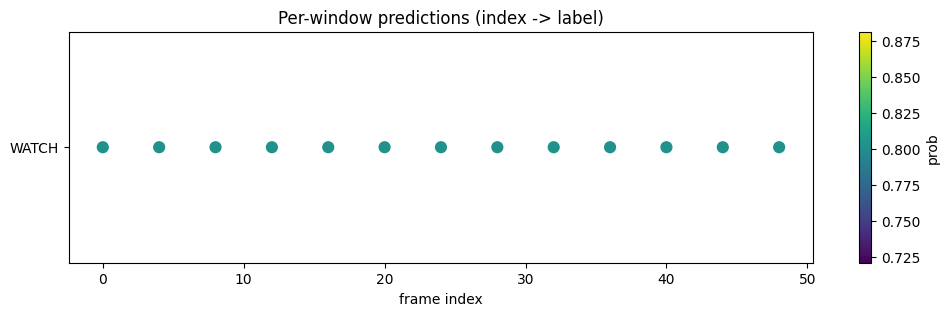

In [24]:
import matplotlib.pyplot as plt

if windows:
    xs = [w[2] for w in windows]
    ys = [w[0] for w in windows]
    probs = [w[1] for w in windows]
    plt.figure(figsize=(12,3))
    plt.scatter(xs, ys, c=probs, cmap='viridis', s=60)
    plt.colorbar(label='prob')
    plt.yticks(sorted(set(ys)), [idx2label[i] for i in sorted(set(ys))])
    plt.xlabel('frame index')
    plt.title('Per-window predictions (index -> label)')
    plt.show()
else:
    print('No window predictions available.')

## 23. Install Flask-CORS for API Serving

Install Flask and Flask-CORS to create a REST API that can receive video frames from the frontend.

In [2]:
%pip install flask flask-cors google-generativeai openai

  Using cached google_api_core-2.28.1-py3-none-any.whl.metadata (3.3 kB)
  Using cached google_api_python_client-2.187.0-py3-none-any.whl.metadata (7.0 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached proto_plus-1.27.0-py3-none-any.whl.metadata (2.2 kB)
  Using cached googleapis_common_protos-1.72.0-py3-none-any.whl.metadata (9.4 kB)
  Using cached pyasn1_modules-0.4.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached rsa-4.9.1-py3-none-any.whl.metadata (5.6 kB)
INFO: pip is looking at multiple versions of grpcio-status to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of grpcio-status to determine which version is compatible with other requirements. This could take a while.
  Using cached pyasn1-0.6.1-py3-none-any.whl.metadata (8.4 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached sniffio-1.3.1-py3-none-any.whl.metadata (3.9 kB)
  Usin

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mediapipe 0.10.9 requires protobuf<4,>=3.11, but you have protobuf 5.29.5 which is incompatible.


## 24. Define Real-Time Frame Processing Function

Create a function to process individual video frames from the webcam stream for real-time inference.

**How it works**:

1. **Frame Buffer Management**:
   - Maintains a sliding window buffer of recent frames
   - Accumulates frames until minimum window size is reached
   - Continuously updates with new frames for real-time processing

2. **Base64 Decoding**:
   - Receives frame data as base64-encoded string
   - Decodes to bytes and converts to OpenCV image format
   - Handles RGB color space for MediaPipe compatibility

3. **Landmark Extraction**:
   - Processes single frame through MediaPipe Holistic
   - Extracts 227-dimensional feature vector
   - Appends to frame buffer

4. **Inference Trigger**:
   - Runs prediction when buffer reaches T_SEQ (32) frames
   - Uses sliding window for continuous predictions
   - Returns prediction immediately for responsiveness

**Returns**: Dictionary containing:
- `predicted_gloss`: The predicted ASL sign name
- `confidence`: Model confidence (0-1)
- `buffer_size`: Current number of frames in buffer
- `processing_time`: Frame processing duration

**Purpose**: Enables real-time sign language translation by processing webcam frames as they arrive.

In [21]:
# Global frame buffer for real-time processing
frame_buffer = deque(maxlen=T_SEQ)
ema_logits_realtime = None
frame_count = 0
MIN_FRAMES_FOR_PREDICTION = 16  # Start predicting with half buffer

def process_frame(frame_base64, alpha=0.6, predict_every_n_frames=1):
    '''
    Process a single frame from webcam for real-time inference.
    
    Args:
        frame_base64 (str): Base64-encoded image frame
        alpha (float): EMA smoothing factor (0.6 = balanced, higher = more responsive)
        predict_every_n_frames (int): Run prediction every N frames (1 = every frame, 2 = every other frame)
    
    Returns:
        dict: Prediction results with gloss, confidence, and metadata
    '''
    global frame_buffer, ema_logits_realtime, frame_count
    
    start_time = time.time()
    
    try:
        # Decode base64 frame
        import base64
        frame_bytes = base64.b64decode(frame_base64.split(',')[1] if ',' in frame_base64 else frame_base64)
        nparr = np.frombuffer(frame_bytes, np.uint8)
        frame = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
        
        if frame is None:
            return {'error': 'Failed to decode frame'}
        
        # Convert to RGB for MediaPipe
        img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        # Extract landmarks
        with mp_holistic.Holistic(static_image_mode=False, model_complexity=1,
                                min_detection_confidence=0.5, min_tracking_confidence=0.5) as holo:
            res = holo.process(img)
            
            vec = np.zeros(227, dtype=np.float32)
            
            # Extract pose landmarks
            if res.pose_landmarks:
                pts = res.pose_landmarks.landmark
                for i, lm in enumerate(pts[:33]):
                    vec[i*3+0] = lm.x
                    vec[i*3+1] = lm.y
                    vec[i*3+2] = lm.z
            
            # Extract left hand landmarks
            offset = 99
            if res.left_hand_landmarks:
                for i, lm in enumerate(res.left_hand_landmarks.landmark[:21]):
                    vec[offset + i*3 + 0] = lm.x
                    vec[offset + i*3 + 1] = lm.y
                    vec[offset + i*3 + 2] = lm.z
                vec[99 + 21*3] = 1.0
            
            # Extract right hand landmarks
            offset = 99 + 21*3 + 1
            if res.right_hand_landmarks:
                for i, lm in enumerate(res.right_hand_landmarks.landmark[:21]):
                    vec[offset + i*3 + 0] = lm.x
                    vec[offset + i*3 + 1] = lm.y
                    vec[offset + i*3 + 2] = lm.z
                vec[offset + 21*3] = 1.0
        
        # Add to buffer
        frame_buffer.append(vec)
        frame_count += 1
        
        # Start predicting once we have minimum frames
        # Continue predicting on sliding window for continuous translation
        if len(frame_buffer) >= MIN_FRAMES_FOR_PREDICTION:
            # Only run prediction every N frames to reduce computation
            if frame_count % predict_every_n_frames == 0:
                # Convert buffer to numpy array
                seq = np.array(frame_buffer)
                
                # Pad if needed (when buffer < T_SEQ)
                if len(seq) < T_SEQ:
                    pad_n = T_SEQ - len(seq)
                    pad = np.repeat(seq[-1:, :], pad_n, axis=0)
                    seq = np.concatenate([seq, pad], axis=0)
                
                # Run inference
                probs = predict_sequence(model, seq, device=DEVICE, apply_normalize=True)
                
                # Apply EMA smoothing for stable continuous predictions
                if ema_logits_realtime is None:
                    ema_logits_realtime = probs
                else:
                    ema_logits_realtime = alpha * probs + (1 - alpha) * ema_logits_realtime
                
                # Get top predictions for continuous display
                pred_idx = int(ema_logits_realtime.argmax())
                pred_prob = float(ema_logits_realtime[pred_idx])
                pred_label = idx2label[pred_idx]
                
                # Get top 5 predictions with probabilities
                top_k = 5
                top_indices = np.argsort(ema_logits_realtime)[-top_k:][::-1]
                top_predictions = [
                    {
                        'label': idx2label[int(i)],
                        'confidence': float(ema_logits_realtime[i])
                    }
                    for i in top_indices
                ]
                
                processing_time = time.time() - start_time
                result = {
                    'predicted_gloss': pred_label,
                    'confidence': pred_prob,
                    'buffer_size': len(frame_buffer),
                    'processing_time': processing_time,
                    'frame_count': frame_count,
                    'top_predictions': top_predictions,
                    'is_continuous': True  # Flag to indicate continuous mode
                }
                print(result)
                return result
            else:
                # Skip prediction this frame, return last known prediction
                if ema_logits_realtime is not None:
                    pred_idx = int(ema_logits_realtime.argmax())
                    pred_prob = float(ema_logits_realtime[pred_idx])
                    pred_label = idx2label[pred_idx]
                    result = {
                        'predicted_gloss': pred_label,
                        'confidence': pred_prob,
                        'buffer_size': len(frame_buffer),
                        'frame_count': frame_count,
                        'skipped_prediction': True  # Indicates using cached prediction
                    }
                    print("Skip")
                    return result 
        
        # Still buffering - need more frames for first prediction
        result = {
            'status': 'buffering',
            'buffer_size': len(frame_buffer),
            'required': MIN_FRAMES_FOR_PREDICTION,
            'message': f'Collecting frames... {len(frame_buffer)}/{MIN_FRAMES_FOR_PREDICTION}'
        }
        print("buffer...")
        return result 
    
    except Exception as e:
        import traceback
        return {
            'error': str(e),
            'traceback': traceback.format_exc()
        }

def reset_buffer():
    '''Reset the frame buffer for a new session.'''
    global frame_buffer, ema_logits_realtime, frame_count
    frame_buffer.clear()
    ema_logits_realtime = None
    frame_count = 0
    return {'status': 'buffer_reset', 'message': 'Frame buffer and state reset successfully'}

## 25. Create Flask API Server with Ngrok Tunnel

Set up a Flask web server to expose the inference model as a REST API, accessible from external applications.

**API Endpoints**:

1. **POST /api/predict-frame**:
   - Accepts single video frame as base64-encoded image
   - Processes through landmark extraction and model inference
   - Returns prediction with confidence score
   - Maintains temporal buffer for smoothing

2. **POST /api/reset**:
   - Clears the frame buffer
   - Resets EMA state
   - Use when starting a new translation session

3. **GET /api/health**:
   - Health check endpoint
   - Returns model status and configuration
   - Verifies service availability

4. **GET /api/labels**:
   - Returns list of all supported ASL signs
   - Provides vocabulary information

**Ngrok Integration**:
- Creates public HTTPS tunnel to Colab instance
- Provides accessible URL for backend connection
- Handles CORS for cross-origin requests
- Enables secure external API access

**Usage**:
1. Run this cell to start the server
2. Copy the ngrok public URL (https://...)
3. Add URL to backend .env as COLAB_INFERENCE_URL
4. Backend can now send frames to this endpoint

**Note**: The server runs in the background. Keep this notebook running for continuous inference.

In [24]:
!pip install requests

     ---------------------------------------- 0.0/64.7 kB ? eta -:--:--
     ------------------ ------------------- 30.7/64.7 kB 435.7 kB/s eta 0:00:01
     ------------------ ------------------- 30.7/64.7 kB 435.7 kB/s eta 0:00:01
     ------------------------------------ - 61.4/64.7 kB 409.6 kB/s eta 0:00:01
     -------------------------------------- 64.7/64.7 kB 386.5 kB/s eta 0:00:00
  Using cached certifi-2026.1.4-py3-none-any.whl (152 kB)
     ---------------------------------------- 0.0/107.2 kB ? eta -:--:--
     --------------------------------- ----- 92.2/107.2 kB 1.3 MB/s eta 0:00:01
     -------------------------------------- 107.2/107.2 kB 1.0 MB/s eta 0:00:00
     ---------------------------------------- 0.0/131.6 kB ? eta -:--:--
     ------------------------------------- -- 122.9/131.6 kB ? eta -:--:--
     ------------------------------------- -- 122.9/131.6 kB ? eta -:--:--
     -------------------------------------- 131.6/131.6 kB 1.1 MB/s eta 0:00:00
  Using cached


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
from flask import Flask, request, jsonify
from flask_cors import CORS
import threading
import time
import os
import json
import requests

In [27]:
# Gemini LLM configuration
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
GEMINI_MODEL = os.getenv("GEMINI_MODEL", "gemini-1.5-flash")

def llm_rerank_predictions(top_predictions, context_text=None):
    """
    Use Gemini to re-rank model hypotheses and propose a clean sentence.

    Returns dict with label, sentence, reason when LLM is available; otherwise None.
    """
    if not top_predictions:
        return None
    if not GEMINI_API_KEY:
        return None

    candidate_lines = [
        f"{i+1}. label='{p['label']}' confidence={round(p['confidence'], 4)}"
        for i, p in enumerate(top_predictions)
    ]
    context_line = context_text or "(no prior context provided)"

    prompt_text = (
        "You improve ASL gloss predictions. Pick the single gloss that fits the",
        " sentence best, even if it has lower confidence. Then write a clean",
        " English sentence using that gloss in context. Return JSON only with",
        " keys label, sentence, reason."
    )

    user_text = (
        f"Context: {context_line}\n"
        f"Candidates:\n" + "\n".join(candidate_lines) + "\n"
        "Respond with JSON like {\"label\":\"...\",\"sentence\":\"...\",\"reason\":\"...\"}."
    )

    url = f"https://generativelanguage.googleapis.com/v1beta/models/{GEMINI_MODEL}:generateContent?key={GEMINI_API_KEY}"
    payload = {
        "contents": [
            {
                "role": "user",
                "parts": [
                    {"text": prompt_text + "\n\n" + user_text}
                ]
            }
        ],
        "generationConfig": {
            "temperature": 0.3,
            "topP": 0.9,
            "maxOutputTokens": 128
        }
    }

    try:
        resp = requests.post(url, json=payload, timeout=8)
        resp.raise_for_status()
        data = resp.json()
        candidates = data.get("candidates")
        if not candidates:
            return None
        text = candidates[0].get("content", {}).get("parts", [{}])[0].get("text", "{}")
        parsed = json.loads(text)
        if isinstance(parsed, dict) and "label" in parsed:
            return {
                "label": parsed.get("label"),
                "sentence": parsed.get("sentence"),
                "reason": parsed.get("reason", "chosen by Gemini for better sentence fit"),
            }
    except Exception as exc:
        # Log and fall back silently
        print(f"LLM re-rank skipped: {exc}")
    return None

# Create Flask app
app = Flask(__name__)
CORS(app)  # Enable CORS for all routes

@app.route('/api/health', methods=['GET'])
def health_check():
    '''Health check endpoint'''
    return jsonify({
        'status': 'healthy',
        'model_type': MODEL_TYPE,
        'num_classes': NUM_CLASSES,
        'sequence_length': T_SEQ,
        'device': str(DEVICE)
    })

@app.route('/api/labels', methods=['GET'])
def get_labels():
    '''Return all supported ASL signs'''
    return jsonify({
        'labels': LABELS,
        'count': len(LABELS)
    })

@app.route('/api/predict-frame', methods=['POST'])
def predict_frame():
    '''Process a single frame and return prediction'''
    try:
        data = request.get_json()

        if 'frame' not in data:
            return jsonify({'error': 'No frame provided'}), 400

        # Process the frame
        result = process_frame(data['frame'], alpha=0.6, predict_every_n_frames=1)

        # Optionally re-rank with Gemini if configured
        context_text = data.get('context')  # optional running sentence or previous outputs
        rerank = llm_rerank_predictions(result.get('top_predictions'), context_text)
        if rerank:
            result['original_predicted_gloss'] = result.get('predicted_gloss')
            result['predicted_gloss'] = rerank.get('label', result.get('predicted_gloss'))
            result['llm_reason'] = rerank.get('reason')
            if rerank.get('sentence'):
                result['llm_sentence'] = rerank['sentence']
            result['used_llm_rerank'] = True
        else:
            result['used_llm_rerank'] = False

        return jsonify(result)

    except Exception as e:
        return jsonify({'error': str(e)}), 500

@app.route('/api/reset', methods=['POST'])
def reset():
    '''Reset the frame buffer'''
    result = reset_buffer()
    return jsonify(result)

@app.route('/api/predict-video', methods=['POST'])
def predict_video_endpoint():
    '''Process a complete video file (for batch processing)'''
    try:
        # This would handle uploaded video files
        # For now, return not implemented
        return jsonify({'error': 'Video upload endpoint - implement if needed'}), 501
    except Exception as e:
        return jsonify({'error': str(e)}), 500

# Function to run Flask in background
def run_flask():
    app.run(host='127.0.0.1', port=5000, debug=False, use_reloader=False)

print("="*60)
print("Starting Flask server for local execution...")
print("="*60)

# Start Flask in a separate thread
flask_thread = threading.Thread(target=run_flask, daemon=True)
flask_thread.start()

# Wait a moment for server to start
time.sleep(2)

local_url = "http://127.0.0.1:5000"
print(f"ASL Inference API is running locally!")
print(f"="*60)
print(f"Local URL: {local_url}")
print(f"API Endpoints:")
print(f"   - POST {local_url}/api/predict-frame")
print(f"   - POST {local_url}/api/reset")
print(f"   - GET  {local_url}/api/health")
print(f"   - GET  {local_url}/api/labels")
print(f"="*60)
print(f"Server is ready to receive requests!")
print(f"="*60)
print()
print("NOTE: This server is accessible only from your local machine.")
print("If you need external access, install pyngrok and uncomment the ngrok code below.")
print()

# Optional: Uncomment the following lines if you want to use ngrok for external access
# Requires: pip install pyngrok
# And setting NGROK_TOKEN environment variable or hardcoding your token

# from pyngrok import ngrok
# NGROK_TOKEN = os.getenv('NGROK_TOKEN')  # Set your token as environment variable
# if NGROK_TOKEN:
#     ngrok.set_auth_token(NGROK_TOKEN)
#     public_url = ngrok.connect(5000)
#     print(f"Ngrok tunnel created: {public_url}")
#     print(f"Add this to your backend .env: COLAB_INFERENCE_URL={public_url}")
# else:
#     print("Ngrok token not found. Server running locally only.")

print("Server is running. Keep this cell running to maintain the API.")
print("To stop the server, interrupt this cell.")

while True:
    print(f"[{time.strftime('%H:%M:%S')}] Server active and listening on {local_url}...")
    time.sleep(60)

 * Tip: There are .env files present. Install python-dotenv to use them.


Starting Flask server for local execution...
 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit


ASL Inference API is running locally!
Local URL: http://127.0.0.1:5000
API Endpoints:
   - POST http://127.0.0.1:5000/api/predict-frame
   - POST http://127.0.0.1:5000/api/reset
   - GET  http://127.0.0.1:5000/api/health
   - GET  http://127.0.0.1:5000/api/labels
Server is ready to receive requests!

NOTE: This server is accessible only from your local machine.
If you need external access, install pyngrok and uncomment the ngrok code below.

Server is running. Keep this cell running to maintain the API.
To stop the server, interrupt this cell.
[15:43:37] Server active and listening on http://127.0.0.1:5000...
[15:44:37] Server active and listening on http://127.0.0.1:5000...


127.0.0.1 - - [16/Feb/2026 15:45:02] "GET /api/health HTTP/1.1" 200 -


...

127.0.0.1 - - [16/Feb/2026 15:49:54] "POST /api/predict-frame HTTP/1.1" 500 -


{'predicted_gloss': 'MILK', 'confidence': 0.18846067786216736, 'buffer_size': 44, 'processing_time': 0.5424814224243164, 'frame_count': 44, 'top_predictions': [{'label': 'MILK', 'confidence': 0.18846067786216736}, {'label': 'PLAY', 'confidence': 0.1748468279838562}, {'label': 'BORED', 'confidence': 0.1412673443555832}, {'label': 'READ', 'confidence': 0.1190861240029335}, {'label': 'PAY', 'confidence': 0.04643929377198219}], 'is_continuous': True}


127.0.0.1 - - [16/Feb/2026 15:49:54] "POST /api/predict-frame HTTP/1.1" 500 -


{'predicted_gloss': 'BORED', 'confidence': 0.26869499683380127, 'buffer_size': 45, 'processing_time': 0.4636828899383545, 'frame_count': 45, 'top_predictions': [{'label': 'BORED', 'confidence': 0.26869499683380127}, {'label': 'MILK', 'confidence': 0.1834215670824051}, {'label': 'READ', 'confidence': 0.13129550218582153}, {'label': 'PLAY', 'confidence': 0.105864018201828}, {'label': 'SAD', 'confidence': 0.04894135147333145}], 'is_continuous': True}


KeyboardInterrupt: 